# Urine Data Analysis

With the cleaned and individually exported data, the dataset is now ready for detailed analysis. The urine lab data will be analyzed first, followed by blood lab analyses.

From the cleaned urine labs, the focus will be on values that are more directly associated with metabolic syndrome and related conditions. The urine labs selected for analysis are:

* Albumin – Used to assess kidney function and nutritional status.
* Creatinine – Another key marker of kidney function.
* Iodine – An essential element for thyroid function, which plays a direct role in metabolism.

These analytes were chosen for their relevance to metabolic health and potential associations with obesity and related physiological outcomes.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
current_directory = os.getcwd()
print(current_directory)

C:\Users\chungs4\Documents\GitHub\portfolio_ds_projects\NHANES_analysis


In [3]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_cr = pd.read_csv('urine_cr_alb.csv')

In [4]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [5]:
df_d.isna().sum()

participant_id              0
gender                      0
age_year                    0
race                        0
education_level          5756
marital_status           5756
family_income_poverty    1847
dtype: int64

In [6]:
df_d.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,14300.000000,14300.000000,14300.000000,14300.000000,8544.000000,8544.000000,12453.000000
mean,117068.670280,1.504545,33.861818,3.482797,3.554775,1.694640,2.385320
std,4501.643618,0.499997,25.162121,1.625440,1.210994,2.613598,1.625954
min,109263.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,113170.750000,1.000000,10.000000,3.000000,3.000000,1.000000,1.010000
50%,117081.500000,2.000000,31.000000,3.000000,4.000000,1.000000,1.940000
75%,120974.250000,2.000000,56.000000,4.000000,4.000000,2.000000,3.850000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


Current data analysis will focus on adults aged 18 or older. Subjects that are younger than 18 will be removed.

In [7]:
adults = df_d[df_d['age_year'] >= 18]

In [8]:
adults.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,8965.000000,8965.000000,8965.000000,8965.000000,8544.000000,8544.000000,7705.000000
mean,117107.849637,1.513999,49.465142,3.484551,3.554775,1.694640,2.558740
std,4501.048325,0.499832,18.457564,1.574461,1.210994,2.613598,1.627623
min,109266.000000,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,113211.000000,1.000000,33.000000,3.000000,3.000000,1.000000,1.170000
50%,117091.000000,2.000000,50.000000,3.000000,4.000000,1.000000,2.160000
75%,121022.000000,2.000000,64.000000,4.000000,4.000000,2.000000,4.140000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


The data frame `adults` was created by only including subjects aged 18 or greater from the demographics dataset. The next step will be to clean the anthropometry dataset by dropping any NaN values in the BMI column, removing unnecessary columns (columns relating to pediatric anthropometry), and merging the datasets `adults` with `df_a`.



In [9]:
df_a.isna().sum()

participant_id                 0
weight_kg                     32
weight_comment             13519
recumbent_length_cm        12637
standing_height              950
standing_height_comment    13936
bmi                          970
bmi_category_child          9358
upper_leg_cm                3123
upper_arm_cm                 617
arm_circumference_cm         623
waist_circ_cm               1533
hip_circ_cm                 4245
dtype: int64

In [10]:
df_a = df_a.dropna(subset=['bmi'])

In [11]:
df_a.isna().sum()

participant_id                 0
weight_kg                      0
weight_comment             12601
recumbent_length_cm        12571
standing_height                0
standing_height_comment    13038
bmi                            0
bmi_category_child          8388
upper_leg_cm                2177
upper_arm_cm                 460
arm_circumference_cm         461
waist_circ_cm                603
hip_circ_cm                 3296
dtype: int64

In [12]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [13]:
df_a = df_a.drop(['recumbent_length_cm','bmi_category_child','weight_comment'], axis = 1)

In [14]:
adults_joined = adults.merge(df_a, on='participant_id')

#### Descriptive Statistics

At this point, the data frame including anthropometry of all of the adults subjects has been created. The first thing to do before focusing on the obese population, a basic descriptive statistics was performed to show the BMI distribution. 

First, a box and whiskers chart was created to display the distribution overall. Median and average of the BMI are in the overweight range. Next, the decision was made to separate the population by gender. The result was similar; however, women had higher average BMI compared to the males in the cohort. 

In [15]:
adults_joined['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

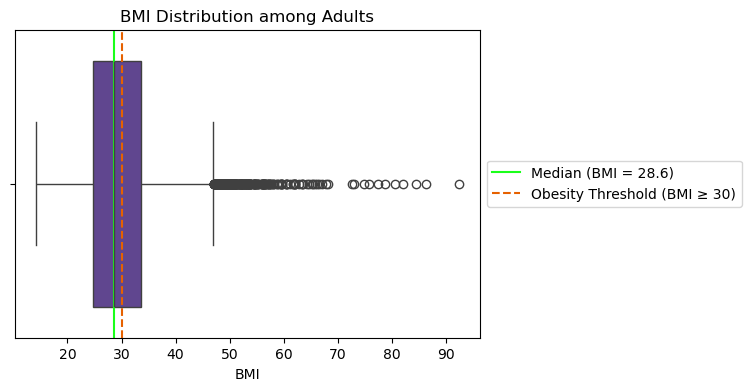

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B')

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even at average, the weight distribution among adults doesn't fall into normal weight. In fact, the mean weight of this dataset, which is supposed to mimic the American population, is in the upper range of overweight bordering obesity. The weight of the Americans are overall increased.

C:\Users\chungs4\AppData\Local\Temp\ipykernel_21368\4023430097.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#5D3A9B'` for the same effect.

  sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B', hue="gender")


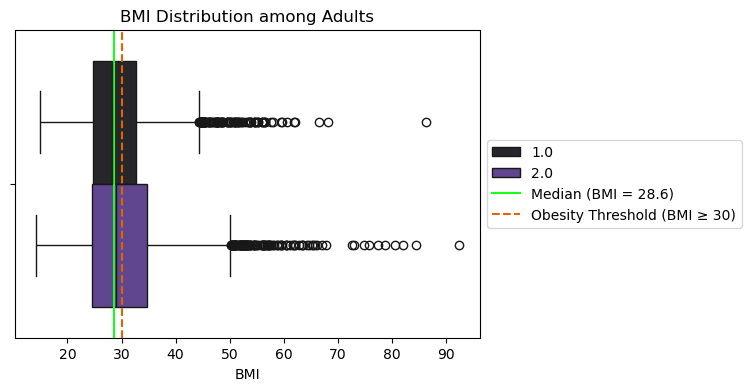

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B', hue="gender")

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In this dataset, the average BMI for women is higher than that for men. This observation aligns with known physiological differences—specifically, the role of estrogen in promoting fat storage, which contributes to higher body fat percentages in women. The dataset has an approximately equal distribution of male and female subjects, so this difference is unlikely to be due to sampling bias.

However, there are notable outliers in the dataset, particularly individuals with a BMI greater than 50. Such high BMI values are rare in the general population and could disproportionately influence the results of the analysis. To assess their impact, the proportion of individuals with BMI over 50 was examined.

It was found that less than 2% of the dataset falls into this category. Given this small proportion, and to reduce the influence of extreme outliers, the decision was made to restrict the analysis to subjects with a BMI of 50 or less.

In [18]:
num_high_bmi = (adults_joined['bmi'] > 50).sum()
print(f"Number of subjects with BMI > 50: {num_high_bmi}")
prop_high_bmi = (adults_joined['bmi'] > 50).mean()
print(f"Proportion of subjects with BMI > 50: {prop_high_bmi:.2%}")

Number of subjects with BMI > 50: 168
Proportion of subjects with BMI > 50: 1.91%


In [19]:
adults_filtered = adults_joined[adults_joined['bmi'] <= 50].copy()

In [20]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

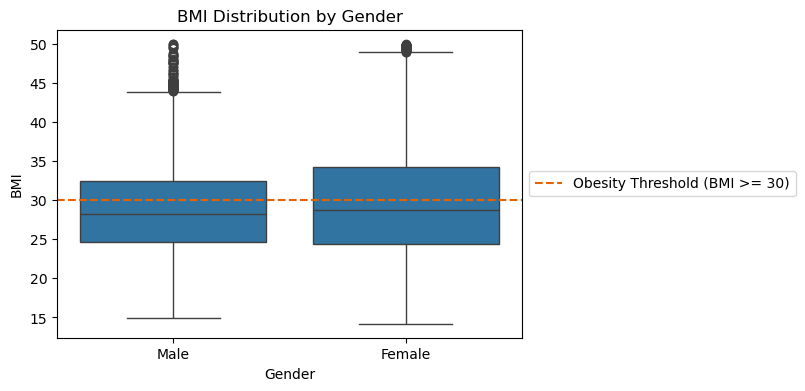

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender',y='bmi',data=adults_filtered)

plt.axhline(30, color='#E66100',linestyle='--', label= "Obesity Threshold (BMI >= 30)")
plt.title("BMI Distribution by Gender")
plt.ylabel('BMI')
plt.xlabel('Gender')
plt.xticks([0,1], ["Male" , "Female"])
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [22]:
gender = adults_filtered.groupby('gender')['bmi'].describe()
gender = gender.rename(index={1: "Male", 2:"Female"})
gender

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Male,4225.0,28.956615,5.970412,14.9,24.7,28.2,32.4,50.0
Female,4397.0,29.742188,7.103129,14.2,24.4,28.8,34.2,50.0


Even after removing outliers, the average BMI of the dataset still falls within the overweight range, reflecting overall trends in the U.S. population. The next step is to isolate subjects classified as obese (BMI ≥ 30) into a separate DataFrame for further analysis.

In [23]:
obese = adults_filtered[adults_filtered['bmi'] >= 30]

In [24]:
obese.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.0,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1
3,109274.0,1.0,68.0,7.0,4.0,3.0,1.2,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8
5,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,39.1,33.0,33.5,38.5,103.1,125.5
8,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,31.3,NaN,NaN,NaN,NaN,NaN
9,109292.0,1.0,58.0,2.0,3.0,2.0,1.6,86.0,167.8,NaN,30.5,38.4,39.5,29.0,108.3,106.4


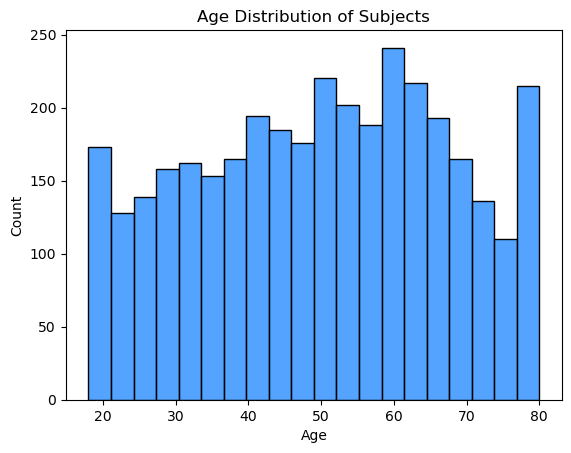

In [25]:
sns.histplot(x='age_year', bins = 20, data=obese, color = '#1A85FF')
plt.title('Age Distribution of Subjects')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Urine Albumin

The first urine biomarker analyzed in relation to BMI is urine albumin. This measurement, along with urine creatinine, is collected via spot tests rather than 24-hour collections. In the NHANES dataset, urine albumin values labeled as '< LOD' or '>1000 µg/mL' are flagged as outliers. For this analysis, the normal reference range is defined as <30 µg/mL, based on findings from Jones et al. (Am J Kidney Dis. 2002;39:445–459). To ensure consistency, only columns reporting values in µg/mL will be retained for further analysis.

In [26]:
df_cralb = pd.read_csv('urine_cr_alb.csv')

In [27]:
urine_cralb = obese.merge(df_cralb, on='participant_id')

In [28]:
adults_cralb = adults_joined.merge(df_cralb, on='participant_id')

In [29]:
urine_cralb.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,...,hip_circ_cm,Unnamed: 0,albumin_urine_ug_mL,albumin_urine_mg_L,alb_comment,creatinine_urine_mg_dL,creatinine_urine_umol_L,creatinine_comment,alb_creat_ratio,collection_year
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,...,126.1,1,5.5,5.5,0.0,36.0,3182.4,0.0,15.28,2017-2020
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,...,107.8,5,12.8,12.8,0.0,120.0,10608.0,0.0,10.67,2017-2020
2,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,...,125.5,11,8.2,8.2,0.0,189.0,16707.6,0.0,4.34,2017-2020
3,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,...,NaN,17,16.4,16.4,0.0,261.0,23072.4,0.0,6.28,2017-2020
4,109293.0,1.0,44.0,3.0,3.0,3.0,0.02,99.4,181.6,NaN,...,120.2,19,7.2,7.2,0.0,57.0,5038.8,0.0,12.63,2017-2020


In [30]:
urine_cralb.shape

(3448, 25)

In [31]:
urine_cralb.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'standing_height', 'standing_height_comment', 'bmi', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'Unnamed: 0', 'albumin_urine_ug_mL', 'albumin_urine_mg_L',
       'alb_comment', 'creatinine_urine_mg_dL', 'creatinine_urine_umol_L',
       'creatinine_comment', 'alb_creat_ratio', 'collection_year'],
      dtype='object')

In [32]:
urine_cralb = urine_cralb[['participant_id','gender','age_year','race','bmi',
'albumin_urine_ug_mL', 'creatinine_urine_mg_dL','alb_creat_ratio']]

In [33]:
urine_cralb.isna().sum()

participant_id            0
gender                    0
age_year                  0
race                      0
bmi                       0
albumin_urine_ug_mL       0
creatinine_urine_mg_dL    0
alb_creat_ratio           0
dtype: int64

With the initial data cleaning, the NaN values have been removed. 

In [34]:
urine_cralb.describe()

,participant_id,gender,age_year,race,bmi,albumin_urine_ug_mL,creatinine_urine_mg_dL,alb_creat_ratio
count,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000
mean,117062.047564,1.545244,49.816995,3.266531,35.782570,63.937558,142.477378,57.838222
std,4564.177792,0.498021,17.155913,1.471719,4.709608,405.712906,88.483911,371.666530
min,109266.000000,1.000000,18.000000,1.000000,30.000000,0.300000,8.000000,0.860000
25%,113031.000000,1.000000,36.000000,3.000000,32.000000,5.500000,76.000000,4.960000
50%,116966.500000,2.000000,51.000000,3.000000,34.600000,10.600000,126.500000,7.880000
75%,121099.500000,2.000000,63.000000,4.000000,38.500000,22.800000,190.000000,16.122500
max,124818.000000,2.000000,80.000000,7.000000,50.000000,14040.000000,609.000000,11055.120000


In [35]:
urine_alb = urine_cralb[['participant_id','gender','age_year','bmi','albumin_urine_ug_mL', 'race']]

In [36]:
urine_alb['albumin_urine_ug_mL'].describe()

count     3448.000000
mean        63.937558
std        405.712906
min          0.300000
25%          5.500000
50%         10.600000
75%         22.800000
max      14040.000000
Name: albumin_urine_ug_mL, dtype: float64

Although the range of the urine albumin can be a bit ambiguous, values that are significantly above 1000 mcg/mL seems to be too extreme. The data was visualized to see how the distribution appears.

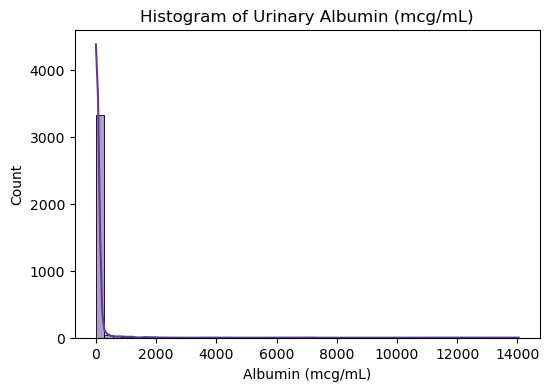

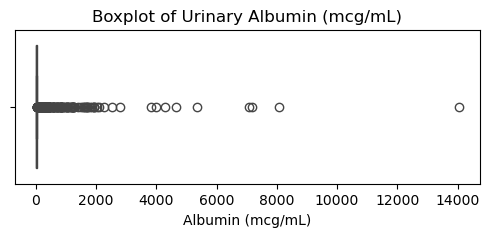

In [37]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(urine_alb['albumin_urine_ug_mL'], bins=50, kde=True, color='#5D3A9B')
plt.title("Histogram of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

Due to variability in how urine albumin ranges are interpreted, excluding outliers is not always appropriate. However, extremely high values—such as the entry near 14,000 µg/mL—fall well outside expected clinical ranges and are likely due to data entry or assay error.

To explore potential associations between elevated urine albumin and BMI, subjects with albumin levels ≥1000 µg/mL were examined. Because the BMI range is wide (30–48), it is unlikely that a significant correlation with elevated albumin levels exists. Additionally, with only 44 subjects—about 1.25% of the dataset—this small group lacks sufficient power for robust statistical analysis. Therefore, these subjects were excluded to preserve a more representative dataset for downstream analysis.

In [41]:
urine_alb[urine_alb["albumin_urine_ug_mL"] >= 1000].describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL,race
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,116317.022727,1.431818,53.090909,36.984091,2555.250000,3.500000
std,4864.374314,0.501056,14.289072,4.526765,2486.739353,1.635365
min,109843.000000,1.000000,27.000000,30.700000,1019.000000,1.000000
25%,111411.750000,1.000000,43.000000,33.275000,1217.500000,2.750000
50%,115144.500000,1.000000,53.500000,36.550000,1675.500000,4.000000
75%,120967.750000,2.000000,60.250000,40.325000,2322.500000,4.000000
max,124464.000000,2.000000,80.000000,48.400000,14040.000000,7.000000


In [42]:
# Define your threshold
threshold = 1000  

# Count how many subjects exceed the threshold
extreme_count = (urine_alb['albumin_urine_ug_mL'] >= threshold).sum()

# Total number of subjects
total_count = urine_alb['albumin_urine_ug_mL'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme albumin values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with albumin values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")


Subjects with extreme albumin values (≥ 1000 µg/mL): 44
Total subjects with albumin values: 3448
Percentage extreme: 1.28%


In [43]:
# Define threshold
threshold = 1000  

# Keep only subjects below threshold
urine_alb_clean = urine_alb[urine_alb['albumin_urine_ug_mL'] < threshold].copy()

print(f"Original: {urine_alb.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_alb_clean.shape[0]} rows")

Original: 3448 rows
After removing extreme albumin values: 3404 rows


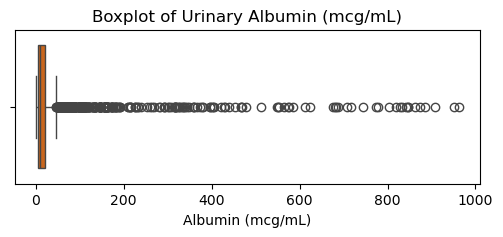

In [44]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb_clean['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

In [45]:
urine_alb_clean.describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL,race
count,3404.000000,3404.000000,3404.000000,3404.000000,3404.000000,3404.000000
mean,117071.677732,1.546710,49.774677,35.767039,31.734929,3.263514
std,4560.132234,0.497887,17.187512,4.710558,85.467464,1.469509
min,109266.000000,1.000000,18.000000,30.000000,0.300000,1.000000
25%,113050.500000,1.000000,36.000000,32.000000,5.400000,3.000000
50%,116979.500000,2.000000,50.000000,34.600000,10.400000,3.000000
75%,121101.750000,2.000000,63.000000,38.500000,21.825000,4.000000
max,124818.000000,2.000000,80.000000,50.000000,962.000000,7.000000


With the outliers removed, the average value of the urine albumin is 31 mcg/mL which is about the reference range from the NHANES study. 

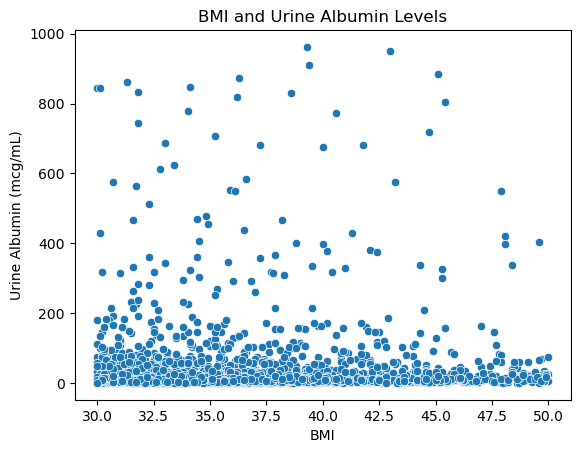

In [46]:
sns.scatterplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean)
plt.xlabel('BMI')
plt.ylabel('Urine Albumin (mcg/mL)')
plt.title('BMI and Urine Albumin Levels')
plt.show()

<Axes: xlabel='bmi', ylabel='albumin_urine_ug_mL'>

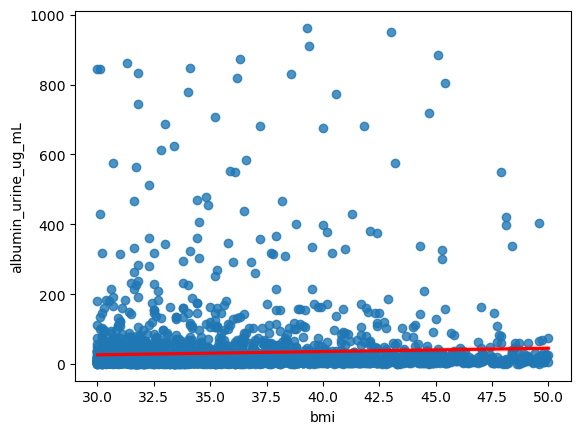

In [47]:
sns.regplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean,line_kws={"color": "red"})

There does not seem to be any linear relationship between the urine albumin level and BMI overall. It will be worthwhile to see whether there is any difference when separated by gender/sex. 

In [48]:
albumin_stats = urine_alb_clean.groupby("gender")["albumin_urine_ug_mL"].describe()
print(albumin_stats)

         count       mean        std  min   25%   50%   75%    max
gender                                                            
1.0     1543.0  36.143487  94.503095  0.4  5.65  10.7  23.7  885.0
2.0     1861.0  28.079688  77.012953  0.3  5.20  10.1  20.9  962.0


1 is male and 2 is female.

C:\Users\chungs4\AppData\Local\Temp\ipykernel_21368\26042211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2", cut=0)


(0.0, 150.0)

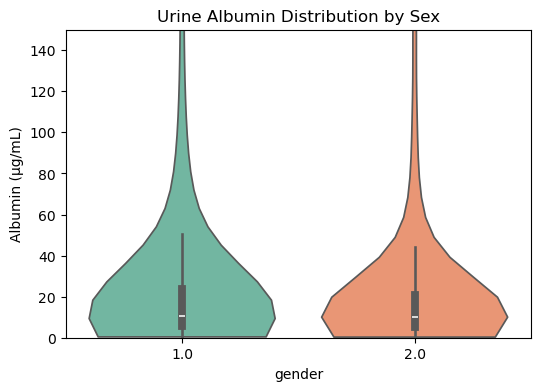

In [49]:
plt.figure(figsize=(6,4))
sns.violinplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2", cut=0)
plt.title("Urine Albumin Distribution by Sex")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0, 150)

C:\Users\chungs4\AppData\Local\Temp\ipykernel_21368\3194978940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")


(0.0, 150.0)

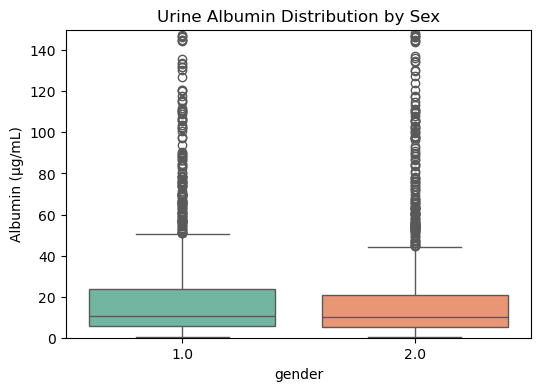

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0,150)

Separation and grouping the data by gender does not seem to change the median value of the urine albumin by much. 

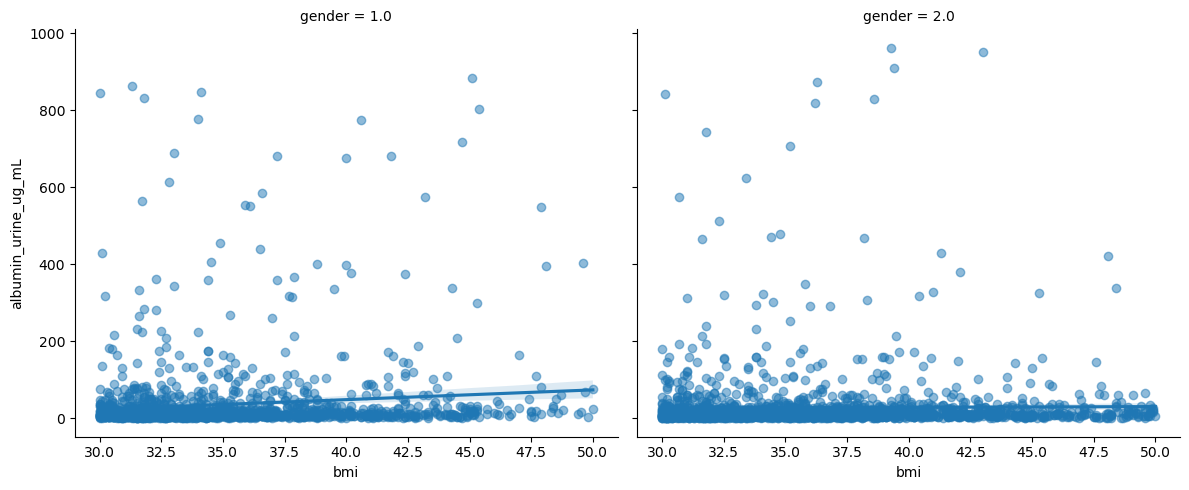

In [52]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    col="gender",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

It appears that the slope of the regression line is slightly higher in the male population than the female population. The correlation will have to be calculated and observed to see whether that is also appreciated in the numeric form.

There seems to be possibly some correlation with "Other" race which includes mixed races. That is a bit difficult to interpret since the race or ethnicity is not specified in that group. 

In [54]:
from scipy.stats import linregress

# Loop over genders
for sex in urine_alb_clean['gender'].unique():
    subset = urine_alb_clean[urine_alb_clean['gender'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['bmi'], subset['albumin_urine_ug_mL'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")

2.0: slope=0.1693, intercept=21.93, r=0.0109, p=0.6378
1.0: slope=2.5274, intercept=-52.58, r=0.1147, p=6.291e-06


When looking at the slope, the raw value is higher in the male population but in the grand scheme of the lab values overall, even comparing to the standard deviation of the lab values, the slope is not impressive.

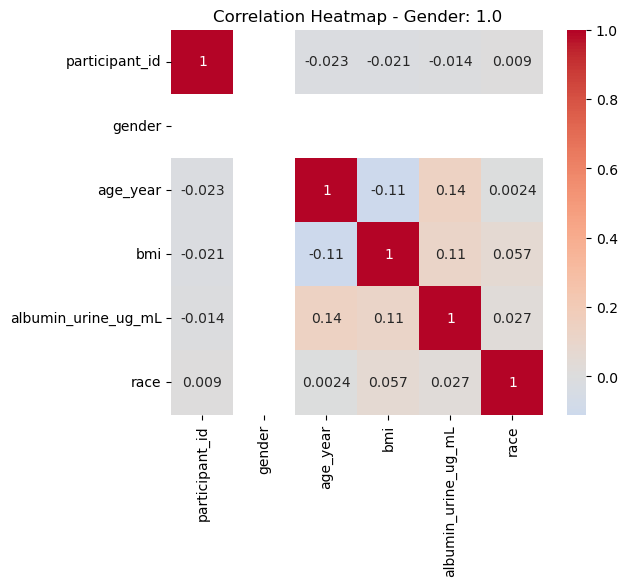

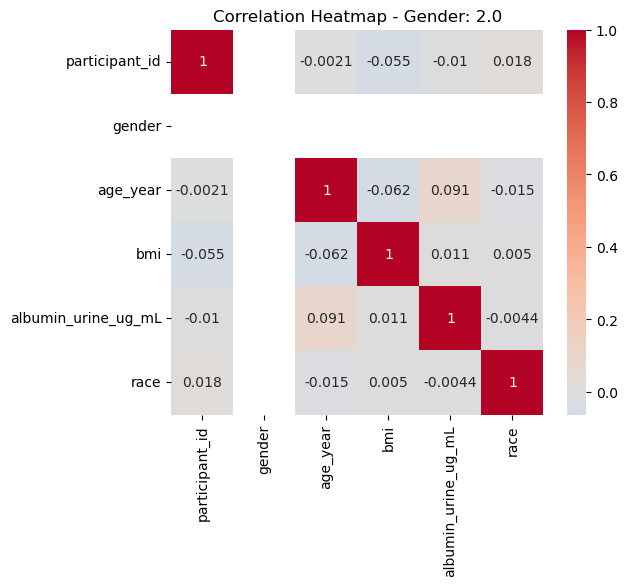

In [57]:
for gender, df_group in urine_alb_clean.groupby('gender'):
    corr_matrix = df_group.corr()
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

The closer to the value of 0, the less there is a relationship between two values. Looking at the correlation table, it does appear that with urine albumin level overall does not seem to have a strong correlation with BMI (0.052). When the genders are separated, the correlation with albumin level seems to be _____.

## Urine Creatinine

Next, urine creatinine will be analyzed.

According to the laboratory test that was performed for the purposes of NHANES, the normal range for urine creatinine is as reported as follows:

 * Urine, adult male, first morning void: 40-278 mg/dL
 * Urine, adult female, first morning void: 29-226 mg/dL

(Mazzachi, et al. From the Roche reagent package insert for enzymatic creatinine.)

In [ ]:
urine_cr = urine_cralb[['participant_id','gender','age_year','race','bmi',
'creatinine_urine_mg_dL']]

In [ ]:
urine_cr.describe()

Because the urine creatinine normal range is varied by gender, the first step is to visualize how the spread differs by the gender. 

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="creatinine_urine_mg_dL", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Creatinine (mg/dL)")
plt.xlabel("Gender")
plt.show()

There are some outliers but it apperas that most of these values fall within the normal range as specified above. The decision was made to keep all of these values, as the outliers do not seem to be skewing the data too much. 

In [ ]:
sns.lmplot(
    x="bmi",
    y="creatinine_urine_mg_dL",
    hue="gender",
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Creatinine vs BMI by Gender")
plt.ylabel("Urine Creatinine (mg/dL)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

The linear regression line does not seem to have a strong slope or correlation. Male subjects seem to have a slightly stronger positive correlation compared to the female subjects but both lines' slopes seem to be minimal. 

In [ ]:
for gender, df_group in urine_cr.groupby('gender'):
    # compute correlation within this gender group
    corr_matrix = df_group.corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

The correlation seen between BMI and urine creatinine is 0.067, which means there is no correlation between those two values. 

## Urine Iodine

Iodine is necessary for thyroid function which contribute to the metabolism in the body. Urine iodine secretion 

Median urinary iodine concentrations of 100–199 mcg/L in children and adults, 150–249 mcg/L in pregnant women and >100 mcg/L in lactating women indicate iodine intakes are adequate (https://ods.od.nih.gov/factsheets/Iodine-HealthProfessional/#:~:text=The%20iodine%2Dreplete%20healthy%20adult,intakes%20are%20adequate%20%5B3%5D.)

In [ ]:
iodine = pd.read_csv('cleaned_u_iodine.csv')

In [ ]:
urine_iodine = obese.merge(iodine, on='participant_id')

In [ ]:
urine_iodine.shape

After joining the tables on `participant_id`, the total number of rows/subjects left is 1119. 

Is there a way to calculate for power? 
Lab results are not normalized so it will have to use non-parametric statistical tests. 

In [ ]:
urine_iodine.head()

In [ ]:
urine_iodine = urine_iodine[['participant_id','race','gender','bmi','urine_iodine']]

In [ ]:
urine_iodine.head()

In [ ]:
urine_iodine.describe()

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

The urine iodine unit is mcg/L. The value that is in the 10,000 seems to be way too excessive. The typical concern with urine iodine is reduced output which equates to inadequate intake to support normal physiological functions. However, the upper range in this cohort is in the 10,000 mcg/L which seems to be excessive. Much like the albumin and creatinine, the outliers should be removed for a proper analysis. From the descriptive statistics and the visualization, having a cutoff of 2500 mcg/L appears to be adequate. 

In [ ]:
# Define your threshold
threshold = 2500  

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

In [ ]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")


In [ ]:
urine_iodine_clean.describe()

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

After removing the values that are greather than or equal to 2500, the plot still shows quite a bit of variance and outliers. The decision was then made to limit the upper value of iodine to 1000 mcg/L.

In [ ]:
# Define your threshold
threshold = 1000 

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine_clean['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine_clean['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

In [ ]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")

In [ ]:
urine_iodine_clean.describe()

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

In [ ]:
sns.lmplot(
    x="bmi",
    y="urine_iodine",
    hue="gender",
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Iodine vs BMI by Gender")
plt.ylabel("Urine Iodine (mcg/L)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

In [ ]:
for gender, df_group in urine_iodine_clean.groupby('gender'):
    # compute correlation within this gender group
    corr_matrix = df_group.corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

There is no strong correlation between BMI and urine iodine levels. The regression plot shows perhaps slight negative correlation but the slope does not seem to be significant. The correlation heatmap shows that there is no substantial correlation between BMI and urine iodine, although the direction of the correlation is negative. 

### Conclusion

Based on the analysis performed with NHANES urine dataset, there was no substantial correlation between the urine creatinine, albumin, or iodine with BMI. There were slight difference between genders in the urine albumin and urine iodine but neither were significant enough to make associations with. 

These findings are reasonable since the urine labs are more related to kidney function and overall nutritional status of a person. Obesity is the pathology caused by metabolic imbalance. 

The next analysis that should be peformed should be comparing how these values differ between normal BMI popultion and obese BMI population. 